                                         descripcion     categoria
0  Mis ventas han bajado mucho este mes, no sé qu...        Ventas
1  Tengo el inventario desordenado, no sé cuánto ...    Inventario
2  Los empleados no llegan a tiempo y la nómina e...        Nomina
3       Mis procesos son un desastre, todo es manual  Organizacion
4  No tengo clientes nuevos, las ventas están est...        Ventas
Total de registros: 15
Categorías: ['Ventas' 'Inventario' 'Nomina' 'Organizacion']
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

  Inventario       0.00      0.00      0.00       2.0
      Nomina       0.00      0.00      0.00       0.0
Organizacion       0.00      0.00      0.00       1.0
      Ventas       0.00      0.00      0.00       2.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

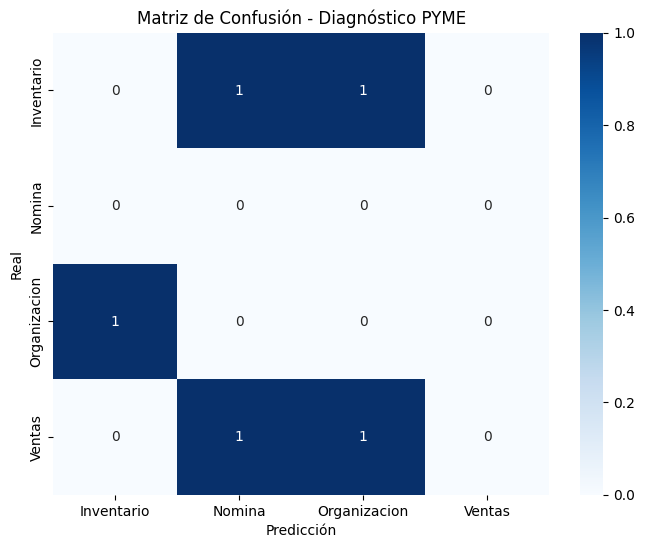

=== RESULTADOS DEL DIAGNÓSTICO ===
Problema: No vendo nada desde hace dos semanas, estoy desesperado
Diagnóstico: Nomina
Confianza: 30.00%
--------------------------------------------------
Problema: Se me acabó el producto estrella y no me di cuenta
Diagnóstico: Nomina
Confianza: 32.37%
--------------------------------------------------
Problema: Los empleados no saben cuánto les toca de prima
Diagnóstico: Nomina
Confianza: 40.31%
--------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
# Dataset de ejemplo basado en problemas reales de PYMES
data = {
 'descripcion': [
 'Mis ventas han bajado mucho este mes, no sé qué hacer',
 'Tengo el inventario desordenado, no sé cuánto tengo',
 'Los empleados no llegan a tiempo y la nómina es un caos',
 'Mis procesos son un desastre, todo es manual',
 'No tengo clientes nuevos, las ventas están estancadas',
 'Se me pierden productos en la bodega',
 'No sé cuánto debo pagarle a cada empleado',
 'Todo está desorganizado, no hay sistemas',
 'Las ventas cayeron un 50% este trimestre',
 'Mi restaurante no controla bien los insumos',
 'Los proveedores me cobran mal y no tengo control',
 'No tengo idea de cuánto gano realmente',
 'Mis empleados se quejan del pago',
 'La tienda está llena pero no vendo lo suficiente',
 'No tengo un sistema para controlar el stock',
 ],
 'categoria': [
 'Ventas', 'Inventario', 'Nomina', 'Organizacion',
 'Ventas', 'Inventario', 'Nomina', 'Organizacion',
 'Ventas', 'Inventario', 'Organizacion', 'Organizacion',
 'Nomina', 'Ventas', 'Inventario'
 ]
}
df = pd.DataFrame(data)
print(df.head())
print(f"Total de registros: {len(df)}")
print(f"Categorías: {df['categoria'].unique()}")

# Paso 3: Preprocesamiento y modelo (celda 2) - This is instructional text and should ideally be in a markdown cell or commented out.
# Copia y ejecuta este código en la segunda celda:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
 df['descripcion'], df['categoria'], test_size=0.3, random_state=42
)
# Crear pipeline: TF-IDF + Naive Bayes
modelo = Pipeline([
 ('tfidf', TfidfVectorizer(stop_words='english')),
 ('clf', MultinomialNB())
])
# Entrenar
modelo.fit(X_train, y_train)
# Predecir
y_pred = modelo.predict(X_test)
# Métricas
print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred))
# Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
 xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.title('Matriz de Confusión - Diagnóstico PYME')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

# Paso 4: Probar el modelo con nuevos datos (celda 3) - This is instructional text and should ideally be in a markdown cell or commented out.
# Copia y ejecuta este código en la tercera celda:
# Probar con descripciones nuevas
nuevos_problemas = [
 "No vendo nada desde hace dos semanas, estoy desesperado",
 "Se me acabó el producto estrella y no me di cuenta",
 "Los empleados no saben cuánto les toca de prima"
]
predicciones = modelo.predict(nuevos_problemas)
probas = modelo.predict_proba(nuevos_problemas)
print("=== RESULTADOS DEL DIAGNÓSTICO ===")
for i, problema in enumerate(nuevos_problemas):
 print(f"Problema: {problema}")
 print(f"Diagnóstico: {predicciones[i]}")
 print(f"Confianza: {max(probas[i]):.2%}")
 print("-" * 50)